In [ ]:

%pip install matplotlib scikit-learn pandas numpy

In [ ]:
%pip install --upgrade numpy matplotlib scikit-learn pandas

In [ ]:
%pip install --upgrade seaborn matplotlib

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

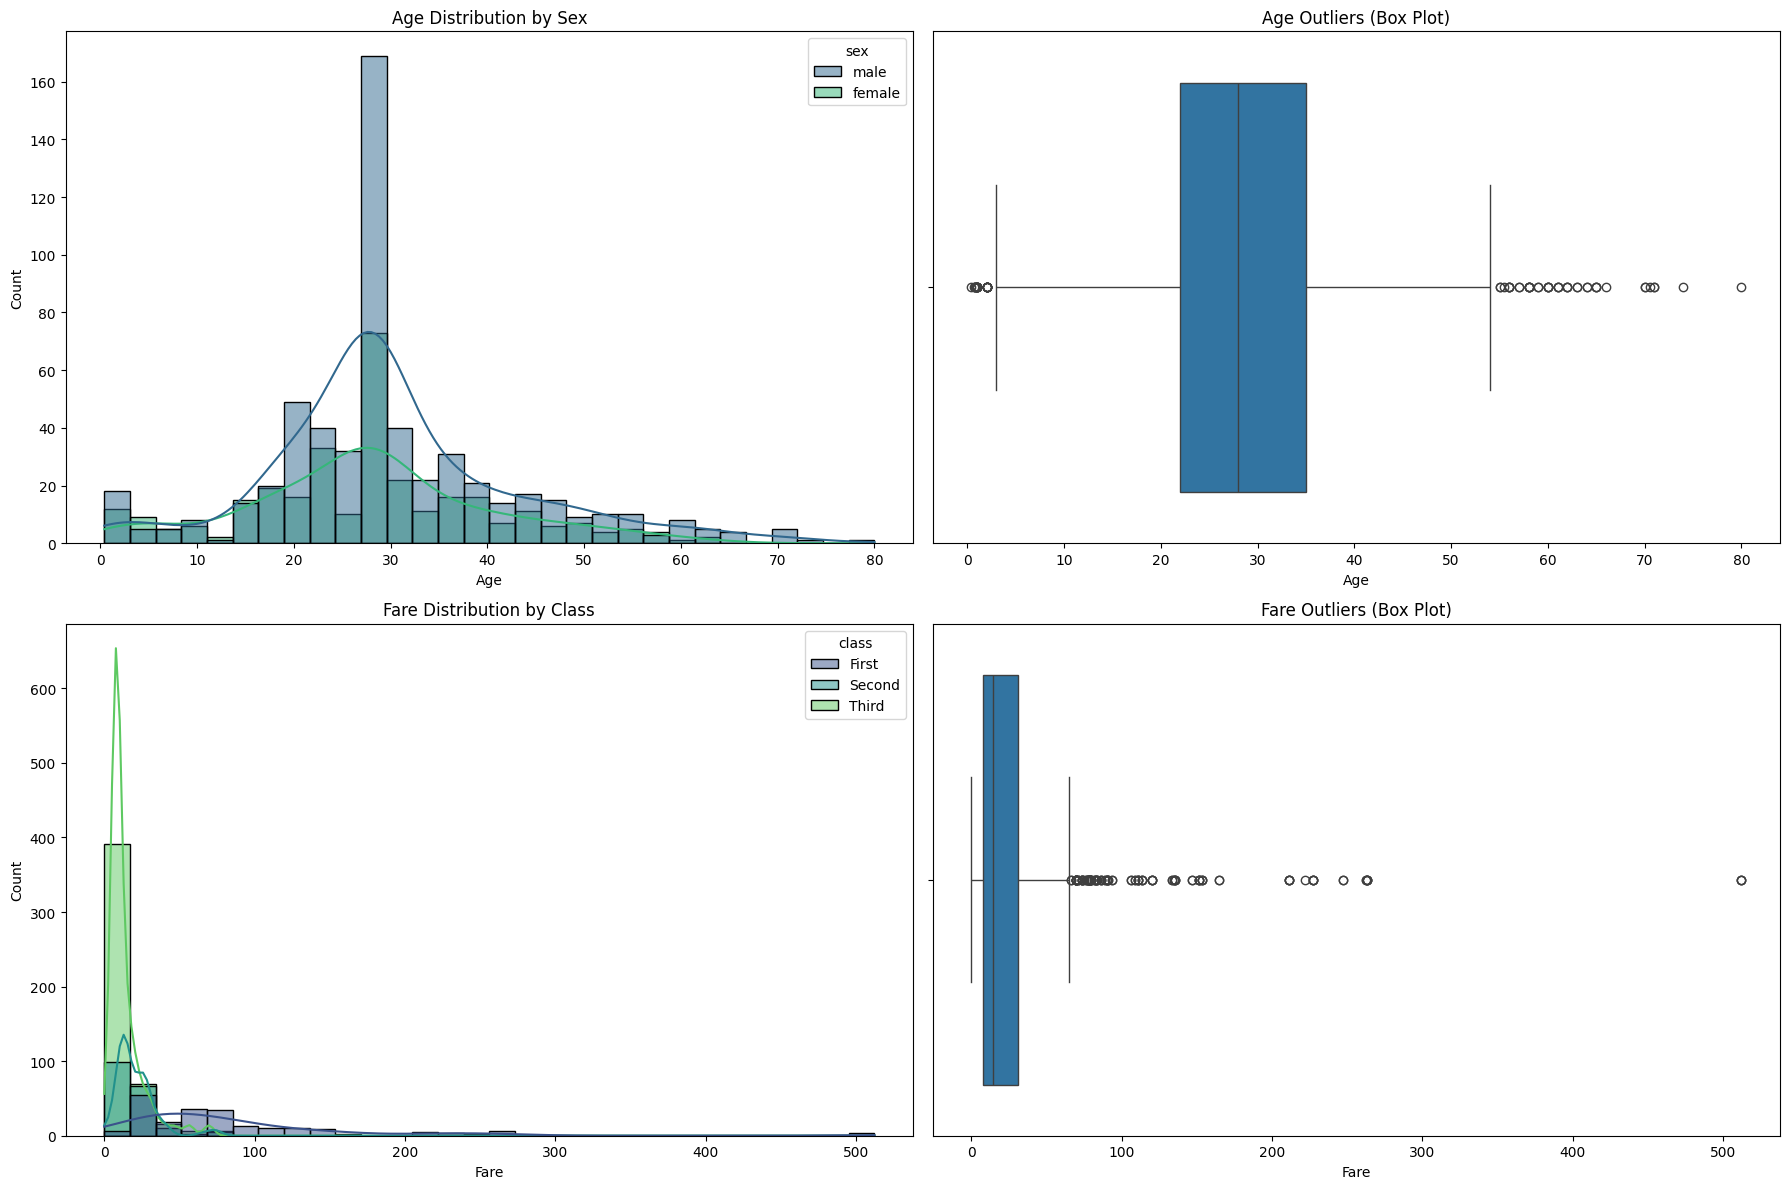


 MALE Survival Rate: 18.89

 FEMALE Survival Rate: 74.04

 Class_1 Survival Rate: 62.62

 Class_2 Survival Rate: 47.28

 Class_3 Survival Rate: 24.24

 MALE Class_1 Survival Rate: 36.89

 FEMALE Class_1 Survival Rate: 96.74

 MALE Class_2 Survival Rate: 15.74

 FEMALE Class_2 Survival Rate: 92.11

 MALE Class_3 Survival Rate: 13.54

 FEMALE Class_3 Survival Rate: 50.00


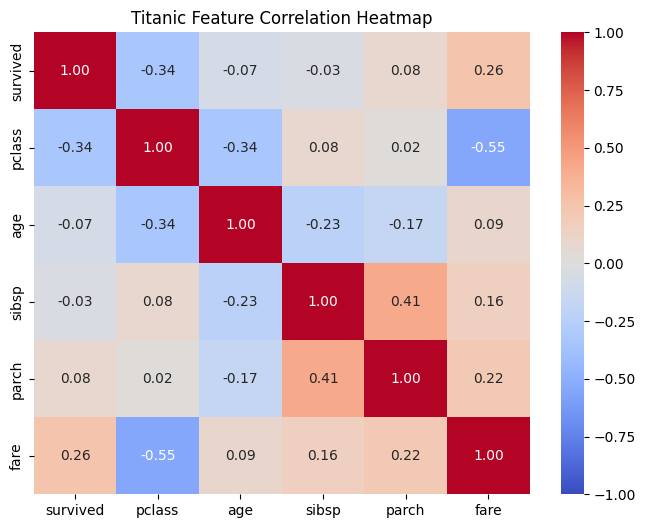

   Variable_1 Variable_2  Correlation  Abs_Correlation
11       fare     pclass    -0.548193         0.548193
9       parch      sibsp     0.414542         0.414542


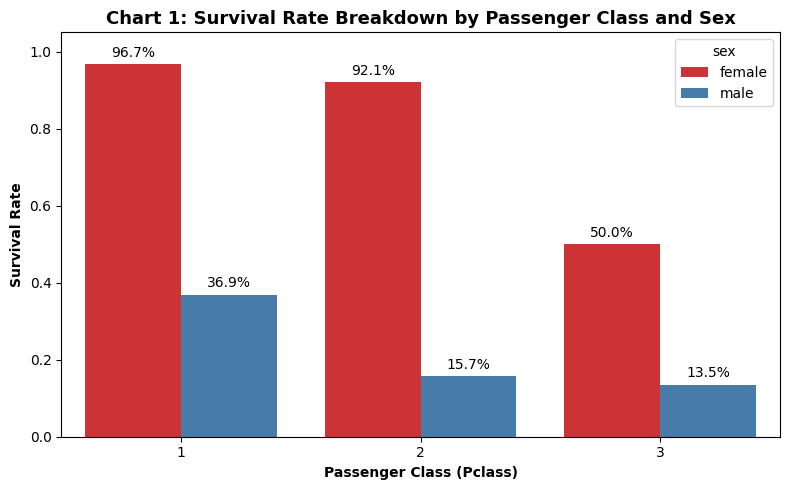

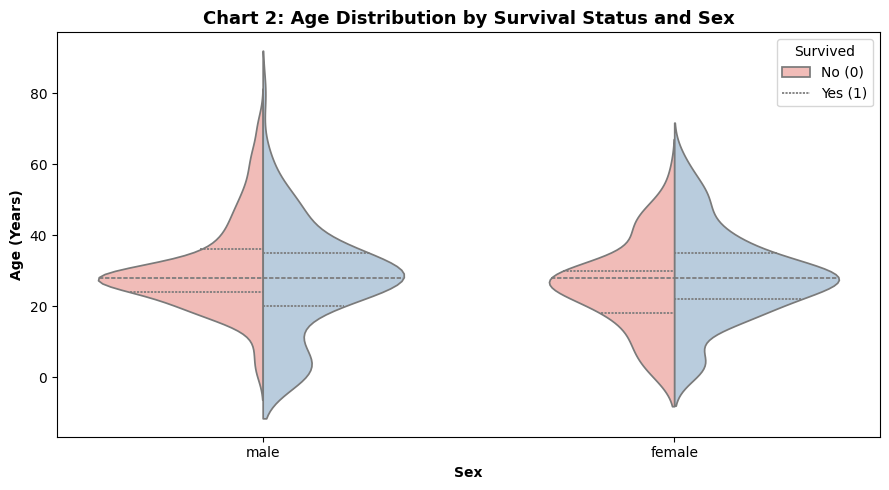

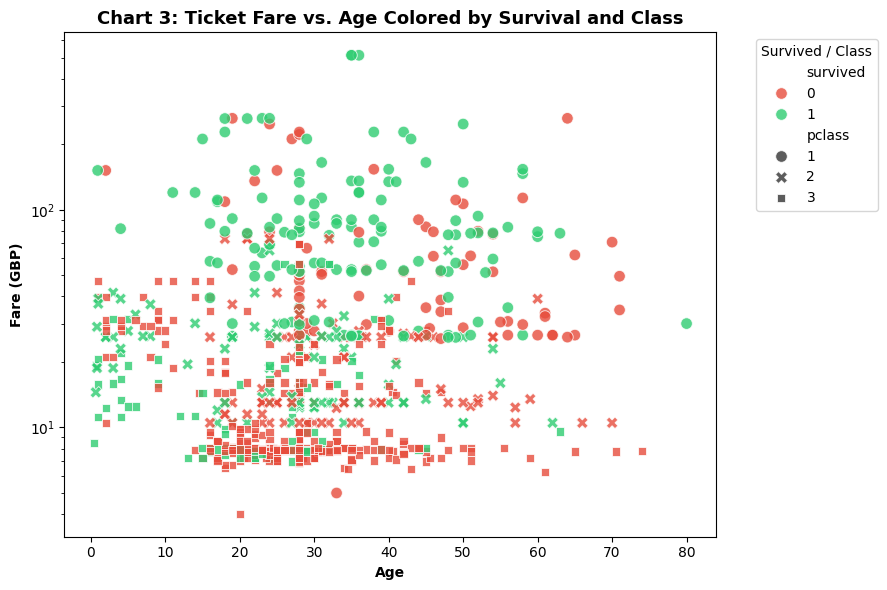

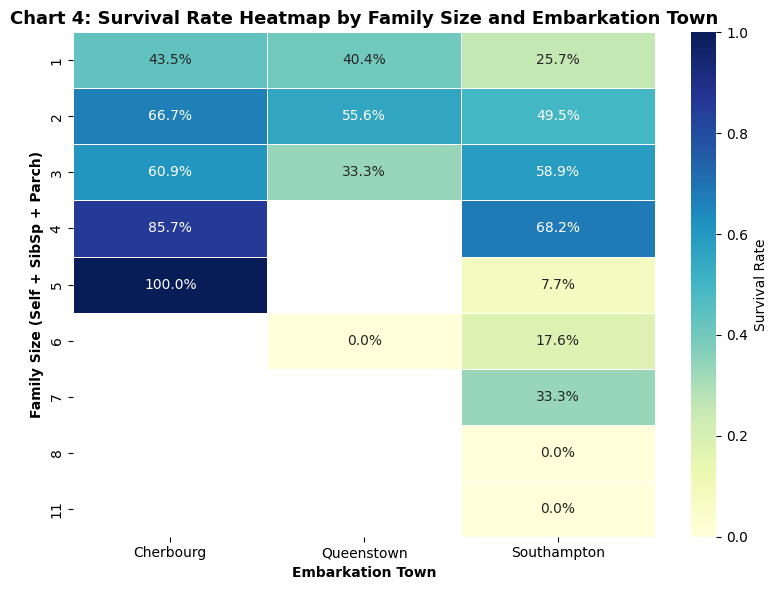

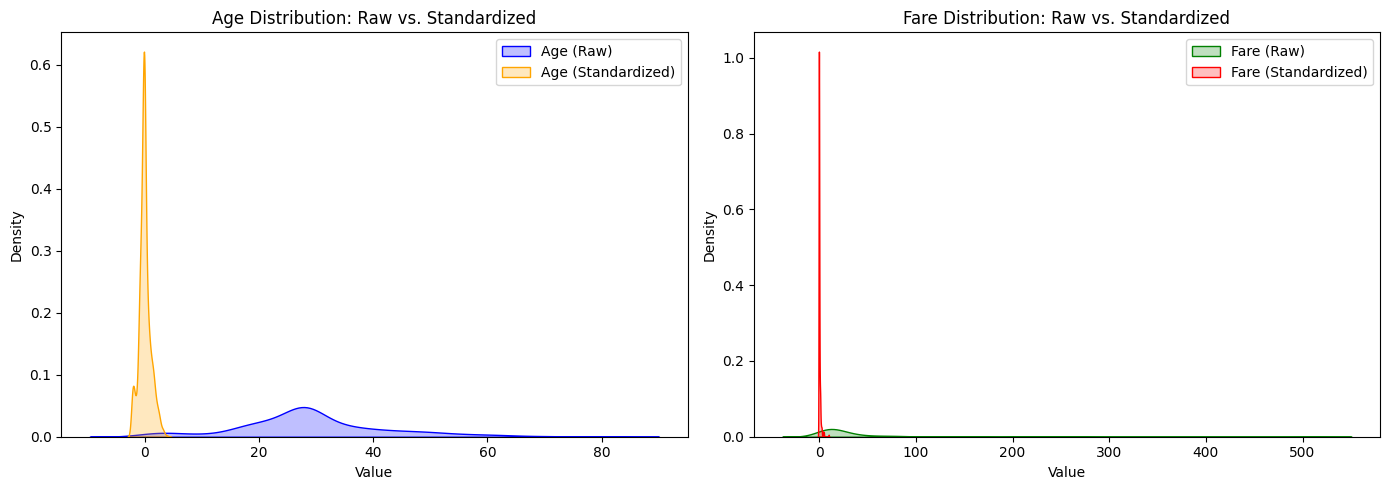

In [2]:
"""
Titanic Dataset Exploration, Cleaning, and Visualization Pipeline.

This script executes Part A of the exploratory data analysis (EDA) pipeline:
  - A.1 Profiling and initial dataset inspection
  - A.2 Handling missing data based on defined thresholds
  - A.3 Univariate analysis (IQR outlier detection, skewness, distributions)
  - A.4 Bivariate analysis (survival rates by demographics, correlation matrix)
  - A.5 Multivariate data story (4 distinct publication-quality charts)
  - A.6 Standardization verification (Raw vs. Z-Score Scaled Distributions)
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler


# _________________________________________________
# Part A — Profiling, cleaning, and the data story
# _________________________________________________

# ===================================
# A.1 Load the dataset and profile it
# ===================================

# Load the built-in Titanic dataset from Seaborn's repository
df = sns.load_dataset("titanic")

# Quick Summary of dataset: prints column names, data types, non-null counts, and memory usage
print(df.info())

# Numeric Statistics for numeric columns: prints count, mean, std, min, quartiles, and max
print(df.describe())

# Return number of rows and columns as a tuple (rows, cols)
print(df.shape)

# Percentage of missing values in every column to determine cleaning strategy
print((df.isna().sum() / len(df)) * 100)

# ===========================
# A.2 Handling Missing Values
# ===========================

# embarked & embark_town (0.22% missing — Under 5% Threshold)
# Dropping rows, <0.3% loss of data has negligible impact on overall sample size while maintaining complete records
df = df.dropna(subset=['embarked', 'embark_town'])

# age (19.87% missing — 5%–30% Threshold)
# Median imputation, preserves sample size without severely distorting the distribution
df['age'] = df['age'].fillna(df['age'].median())

# deck (77.10% missing — Above 30% Threshold)
# Explicitly dropped the column entirely
# Over 77% missing data makes standard imputation unreliable and risks introducing high noise or artificially biased patterns into the predictive models
df = df.drop(columns=['deck'])

# Export a cleaned copy to CSV for external committed offline fallback
df.to_csv("titanic.csv", index=False)

# =======================
# A.3 Univariate Analysis
# =======================

# Define continuous numerical columns for outlier detection and distributional checks
cols = ['age', 'fare']

# Compute IQR (Interquartile Range) outlier bounds for age and fare
for col in cols:
    # Calculate 25th (Q1) and 75th (Q3) percentiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate Lower and Upper bounds (1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    '''
    The IQR method's lower bound is negative here since fare's distribution is heavily right-skewed rather than symmetric.
    So in practice only the upper bound (65.66) identifies meaningful outliers.
    '''
    upper_bound = Q3 + 1.5 * IQR

    # Count total rows falling outside the calculated boundaries
    outliers_count = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()

    # Output summary statistics for outliers
    print(f"--- {col.upper()} OUTLIER ANALYSIS ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Number of Outliers: {outliers_count}\n")

# Measure central tendencies of 'fare' to evaluate distribution asymmetry
fare_mean = f"{df['fare'].mean():.2f}"
fare_median = f"{df['fare'].median():.2f}"
fare_mode = f"{df['fare'].mode()[0]:.2f}"

print("Skewness Analysis for fare:")
print(f"Mean: {fare_mean}")
print(f"Median: {fare_median}")
print(f"Mode: {fare_mode}")

"""
Mean: 32.10
Median: 14.45
Mode: 8.05

Mean(32.10) > Median(14.45) > Mode(8.05)

The fare distribution is strongly right-skewed (positively skewed).
A small number of high-paying first-class passengers pulled the mean significantly above the median and mode.

"""

# Create a 2x2 grid of subplots for univariate visualizations
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Plot histograms with KDE curves on the left column, boxplots on the right column
for i, col in enumerate(cols):
    # Histogram Plot (with categorical hue breakdown)
    sns.histplot(
            data=df,
            x=col,
            hue="sex" if col == "age" else "class",
            bins=30,
            kde=True,
            palette='viridis',
            ax=axes[i * 2],
        )
    axes[i * 2].set_title(f"{col.capitalize()} Distribution by {'Sex' if col == 'age' else 'Class'}")
    axes[i * 2].set_xlabel(col.capitalize())
    axes[i * 2].set_ylabel("Count")

    # Box Plot (for visual outlier identification)
    sns.boxplot(data=df, x=col, ax=axes[i * 2 + 1])
    axes[i * 2 + 1].set_title(f"{col.capitalize()} Outliers (Box Plot)")
    axes[i * 2 + 1].set_xlabel(col.capitalize())

# Adjust spacing and export univariate figure
plt.tight_layout()
plt.savefig("univariate_analysis.png", dpi=150)
plt.show()

# ==================
# A.4 Bivariate Analysis
# ==================

# Use boolean masking (with &/| combinations)
# compute and report survival rate broken down by (a) sex, (b) pclass, and (c) sex and pclass together

# Survival Rate Breakdown by 'sex'
genders = ['male', 'female']

for gender in genders:
      total = df[df['sex'] == gender].shape[0]
      survived = df[(df['sex'] == gender) & (df['survived'] == 1)].shape[0]

      survival_rate = (survived / total) * 100
      print(f"\n {gender.upper()} Survival Rate: {survival_rate:.2f}")

# Survival Rate Breakdown by 'pclass'
pclasses = [1, 2, 3]

for num in pclasses:
      total = df[df['pclass'] == num].shape[0]
      survived = df[(df['pclass'] == num) & (df['survived'] == 1)].shape[0]

      survival_rate = (survived / total) * 100
      print(f"\n Class_{num} Survival Rate: {survival_rate:.2f}")

# Survival Rate Breakdown by 'pclass' and 'sex' together
for num in pclasses:
      for gender in genders:
          total_rate = df[(df['pclass'] == num) & (df['sex'] == gender)].shape[0]
          survived_rate = df[(df['pclass'] == num)& (df['sex'] == gender)& (df['survived'] == 1)].shape[0]

          survival_percent = (survived_rate / total_rate) * 100
          print(f"\n {gender.upper()} Class_{num} Survival Rate:"f" {survival_percent:.2f}")

# Plot Pearson correlation matrix heatmap
plt.figure(figsize=(8, 6))
# Exclude 'adult_male' and 'alone' from the correlation matrix to reduce collinearity redundancy
corr_matrix = df.drop(columns=['adult_male', 'alone']).corr(numeric_only=True)
sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        fmt=".2f",
    )

plt.title("Titanic Feature Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

# Extract upper triangle of correlation matrix to isolate unique variable pairs
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_tri = corr_matrix.where(mask)

# Unstack to convert matrix to long format and drop NaN values (the masked parts)
pairs = upper_tri.unstack().dropna().reset_index()
pairs.columns = ["Variable_1", "Variable_2", "Correlation"]

# Compute absolute value and sort to identify top 2 strongest correlations
pairs["Abs_Correlation"] = pairs["Correlation"].abs()
top_2_pairs = pairs.sort_values(by="Abs_Correlation", ascending=False).head(2)
print(top_2_pairs)

"""
1) Fare and Pclass (-0.55):
There is a strong negative correlation between fare and pclass.
This indicates that passengers in lower pclass categories paid significantly lower fares, while those in higher pclass categories paid higher fares.
This is an expected relationship, as pclass directly reflects the class of travel and associated cost.

2) Parch and SibSp (0.41):
There is a moderately strong positive correlation between parch and sibsp.
This suggests that individuals traveling with more parents/children also tended to be traveling with more siblings/spouses.
This is logical, as both features represent the size and composition of a family unit traveling together on the Titanic.
A larger family group would likely contribute to higher counts in both these categories.
"""

# ==============================
# A.5 Multivariate "Data Story":
# ==============================

# -------------------------------------------------------------------------
# Chart 1: Survival Rate by Sex and Pclass (Bar Plot)
# -------------------------------------------------------------------------

plt.figure(figsize=(8, 5))
ax1 = sns.barplot(
        data=df,
        x="pclass",
        y="survived",
        hue="sex",
        palette="Set1",
        errorbar=None,
    )
plt.title("Chart 1: Survival Rate Breakdown by Passenger Class and Sex",fontsize=13,fontweight="bold",)
plt.xlabel("Passenger Class (Pclass)", fontweight="bold")
plt.ylabel("Survival Rate", fontweight="bold")
plt.ylim(0, 1.05)

# Annotate exact percentage values above each bar
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(
                f"{height:.1%}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                xytext=(0, 3),
                textcoords="offset points",
            )

plt.tight_layout()
plt.savefig("chart1_survival_sex_pclass.png", dpi=300)
plt.show()

"""
Story it says:
A grouped bar plot showing the mean survival rate on the y-axis, grouped by passenger class on the x-axis with separate colored bars for male & female.
Across every class, women survived at dramatically higher rates than men.
Survival rates decline step-by-step from 1st to 3rd class for both genders.
First-class women had near-certain survival (~96.8%), while third-class men had the lowest survival chance (~13.5%).
"""

# -------------------------------------------------------------------------
# Chart 2: Age Distribution by Survival Status across Sex (Violin Plot)
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 5))
sns.violinplot(
        data=df,
        x="sex",
        y="age",
        hue="survived",
        split=True,
        inner="quartile",
        palette="Pastel1",
    )
plt.title("Chart 2: Age Distribution by Survival Status and Sex",fontsize=13,fontweight="bold")
plt.xlabel("Sex", fontweight="bold")
plt.ylabel("Age (Years)", fontweight="bold")
plt.legend(title="Survived", labels=["No (0)", "Yes (1)"])

plt.tight_layout()
plt.savefig("chart2_age_sex_survival.png", dpi=300)
plt.show()

"""
Story it says:
A split violin plot where the vertical axis represents passenger age (0 to 80 years) and the horizontal axis splits by sex.
Each side of the "violin" represents a survival outcome (0 = Died vs. 1 = Survived).
The width of the violin at any age shows data density (how many passengers were that age).
Looking at the male violin on the "Survived" side, there is a distinct wide bulge at the very bottom (ages 0–10).
This proves that young boys were prioritized for lifeboats despite adult males suffering heavy mortality.
For adult males (ages 18–50), the violin is vastly wider on the "Died" side, showing that adult men made up the largest group of casualties.
"""

# -------------------------------------------------------------------------
# Chart 3: Fare vs. Age colored by Survival Status (Scatter Plot)
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 6))
sns.scatterplot(
        data=df,
        x="age",
        y="fare",
        hue="survived",
        style="pclass",
        palette={0: "#e74c3c", 1: "#2ecc71"},
        alpha=0.8,
        s=70,
    )
plt.title("Chart 3: Ticket Fare vs. Age Colored by Survival and Class",fontsize=13,fontweight="bold")
plt.xlabel("Age", fontweight="bold")
plt.ylabel("Fare (GBP)", fontweight="bold")
plt.yscale("log")  # Using log scale due to severe right-skewness in fare
plt.legend(title="Survived / Class", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("chart3_fare_age_survival.png", dpi=300)
plt.show()

"""
Story it says:
A scatter plot with age on the x-axis and fare on the logarithmic y-axis.
Each point represents an individual passenger, color-coded by survival status & shape-coded by passenger class (pclass).
Green dots heavily cluster near the top of the chart, confirming that passengers paying premium fares survived at far higher rates regardless of age.
Passengers paying high fares occupied luxury first-class cabins located on upper decks, giving them immediate physical access to the boat deck during the sinking.
Lower-fare passengers were situated in deeper lower-deck cabins.
"""

# -------------------------------------------------------------------------
# Chart 4: Heatmap of Survival Rates across Family Size and Embarkation Port
# -------------------------------------------------------------------------

# Feature Engineering: Combine siblings/spouses and parents/children to derive total family size
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Create pivot table computing mean survival rate across family size and embarkation port
family_port_pivot = df.pivot_table(
        index="family_size",
        columns="embark_town",
        values="survived",
        aggfunc="mean",
    )

plt.figure(figsize=(8, 6))
sns.heatmap(
        family_port_pivot,
        annot=True,
        fmt=".1%",
        cmap="YlGnBu",
        cbar_kws={"label": "Survival Rate"},
        linewidths=0.5,
    )
plt.title("Chart 4: Survival Rate Heatmap by Family Size and Embarkation Town",fontsize=13,fontweight="bold")
plt.xlabel("Embarkation Town", fontweight="bold")
plt.ylabel("Family Size (Self + SibSp + Parch)", fontweight="bold")

plt.tight_layout()
plt.savefig("chart4_family_port_heatmap.png", dpi=300)
plt.show()

"""
Story it says:
A 2D grid matrix where the rows represent total family_size (1 to 11 people) and the columns represent the embarkation_town.
Cell colors range from light to dark blue, with annotated survival percentages printed inside each block.
Small family units of 2 to 4 people achieved the highest overall survival rates.
They benefited from mutual assistance during the crisis without the burden of coordinating a large group.
Solo travelers (family size = 1) had lower survival rates due to lack of support.
Large families suffered severe mortality, as keeping large groups together in the panic proved difficult.
"""

# =========================================================================
# Feature Scaling Verification: Standardizing Continuous Variables
# =========================================================================

# Extract clean 1D Series for raw Age and Fare
age_raw = df['age'].dropna()
fare_raw = df['fare'].dropna()

# Initialize Scikit-Learn's Z-Score Scaler: z = (x - mean) / std
scaler = StandardScaler()

# Reshape 1D Series to 2D column vector for StandardScaler, then flatten back to 1D for plotting
age_scaled = scaler.fit_transform(age_raw.values.reshape(-1, 1)).flatten()
fare_scaled = scaler.fit_transform(fare_raw.values.reshape(-1, 1)).flatten()

# Create visual comparison overlay (Raw vs. Standardized distributions via KDE plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Comparison Plot
sns.kdeplot(age_raw, ax=axes[0], color='blue', label='Age (Raw)', fill=True)
sns.kdeplot(
        age_scaled,
        ax=axes[0],
        color='orange',
        label='Age (Standardized)',
        fill=True,
    )
axes[0].set_title('Age Distribution: Raw vs. Standardized')
axes[0].set_xlabel('Value')
axes[0].legend()

# Fare Comparison Plot
sns.kdeplot(
        fare_raw, ax=axes[1], color='green', label='Fare (Raw)', fill=True
    )
sns.kdeplot(
        fare_scaled,
        ax=axes[1],
        color='red',
        label='Fare (Standardized)',
        fill=True,
    )
axes[1].set_title('Fare Distribution: Raw vs. Standardized')
axes[1].set_xlabel('Value')
axes[1].legend()

plt.tight_layout()
plt.savefig("Age and Fare Distribution: Raw vs Standardized.png", dpi=300)
plt.show()
